## Import Libraries

In [ ]:
import os, zipfile, random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import tensorflow as tf
from tensorflow.keras.utils import img_to_array
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input

from scipy.linalg import sqrtm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
tf.random.set_seed(SEED)

## Load Dataset

### Upload and Extract Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

zip_path = "archive.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset berhasil diekstrak.")

Saving archive.zip to archive.zip
Dataset berhasil diekstrak.


In [ ]:
base_dir = os.path.join(extract_path, "version2")
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

CLASSES = ["ship", "helicopter"]
IMG_SIZE = (28, 28)

### Load Picture (Ship & Helicopter)

In [ ]:
all_images = []
all_labels = []

for split_name, split_dir in [("train", train_dir), ("test", test_dir)]:
    for label in CLASSES:
        class_folder = os.path.join(split_dir, label)
        image_files = os.listdir(class_folder)
        print(f"{label} ({split_name}) : {len(image_files)} gambar")

        for file in image_files:
            img_path = os.path.join(class_folder, file)
            image = Image.open(img_path)
            image = image.convert("L")
            image = image.resize(IMG_SIZE)
            image = img_to_array(image)
            all_images.append(image)
            all_labels.append(label)

all_images = np.array(all_images, dtype=np.float32)
label_map = {"ship": 0, "helicopter": 1}
idx_to_class = {v: k for k, v in label_map.items()}
all_labels = np.array([label_map[label] for label in all_labels], dtype=np.int64)

print(f"\nTotal seluruh gambar : {all_images.shape}")
print(f"Distribusi kelas : {dict(Counter(all_labels))}")

ship (train) : 7124 gambar
helicopter (train) : 5250 gambar
ship (test) : 888 gambar
helicopter (test) : 656 gambar

Total seluruh gambar : (13918, 28, 28, 1)
Distribusi kelas : {np.int64(0): 8012, np.int64(1): 5906}


### Scaling

In [ ]:
all_images = (all_images / 127.5) - 1.0

print(f"Pixel min : {all_images.min():.1f}")
print(f"Pixel max : {all_images.max():.1f}")

Pixel min : -1.0
Pixel max : 1.0


### Data Example

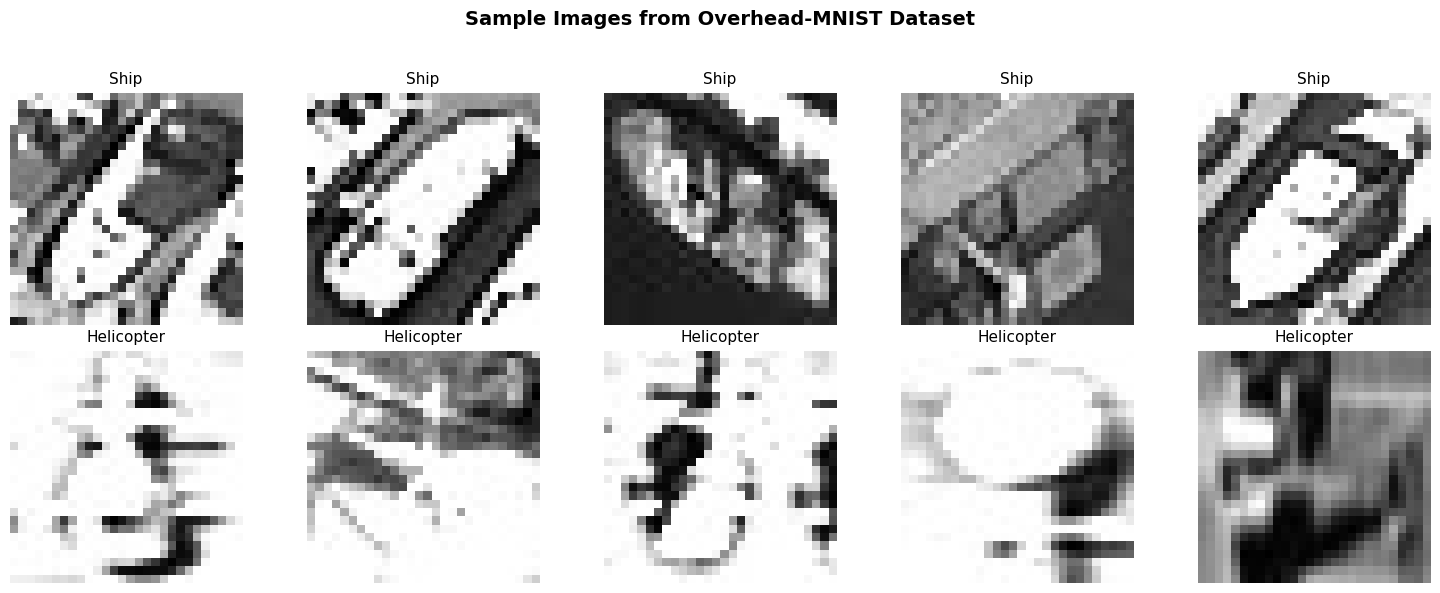

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Sample Images from Overhead-MNIST Dataset", fontsize=14, fontweight="bold")

for row_idx, cls in enumerate(CLASSES):
    label_id = label_map[cls]
    idx_list = np.where(all_labels == label_id)[0][:5]

    for col_idx, img_idx in enumerate(idx_list):
        ax = axes[row_idx, col_idx]
        ax.imshow((all_images[img_idx].squeeze() + 1) / 2, cmap="gray")
        ax.set_title(cls.capitalize(), fontsize=11)
        ax.axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Splitting Data

In [ ]:
X_trainval, x_test, y_trainval, y_test = train_test_split(
    all_images,
    all_labels,
    test_size=0.10,
    random_state=SEED,
    stratify=all_labels
)

x_train, x_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=(1/9),
    random_state=SEED,
    stratify=y_trainval
)

N = len(all_images)
print("Training Set   :", x_train.shape, f"  ({len(x_train)/N*100:.1f}%)")
print("Validation Set :", x_val.shape,   f"  ({len(x_val)/N*100:.1f}%)")
print("Testing Set    :", x_test.shape,  f"  ({len(x_test)/N*100:.1f}%)")

print("\nTraining")
print(Counter(y_train))
print("\nValidation")
print(Counter(y_val))
print("\nTesting")
print(Counter(y_test))

Training Set   : (11134, 28, 28, 1)   (80.0%)
Validation Set : (1392, 28, 28, 1)   (10.0%)
Testing Set    : (1392, 28, 28, 1)   (10.0%)

Training
Counter({np.int64(0): 6410, np.int64(1): 4724})

Validation
Counter({np.int64(0): 801, np.int64(1): 591})

Testing
Counter({np.int64(0): 801, np.int64(1): 591})


## Dataset & DataLoader

In [ ]:
class OverheadMNISTDataset(Dataset):
    def __init__(self, images, labels):
        self.images = torch.from_numpy(images).permute(0,3,1,2).float()
        self.labels = torch.tensor(labels,dtype=torch.long)

    def __len__(self):
        return len(self.images)

    def __getitem__(self,idx):
        return self.images[idx], self.labels[idx]

train_dataset = OverheadMNISTDataset(x_train, y_train)
val_dataset = OverheadMNISTDataset(x_val, y_val)
test_dataset = OverheadMNISTDataset(x_test, y_test)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Validation batches : {len(val_loader)}")
print(f"Test batches : {len(test_loader)}")

sample_images, sample_labels = next(iter(train_loader))

print(f"Batch image shape : {sample_images.shape}")
print(f"Batch label shape : {sample_labels.shape}")

Train batches : 173
Validation batches : 22
Test batches : 22
Batch image shape : torch.Size([64, 1, 28, 28])
Batch label shape : torch.Size([64])


## Baseline

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LATENT_DIM = 100
print("Device :", DEVICE)

Device : cuda


In [ ]:
IMG_SIZE = 28
IMG_CHANNELS = 1
IMG_PIXELS = IMG_SIZE * IMG_SIZE * IMG_CHANNELS

N_CLASSES = len(CLASSES)
LATENT_DIM = 100
EMBED_DIM = 50

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_embedding = nn.Embedding(N_CLASSES, EMBED_DIM)
        self.model = nn.Sequential(
            nn.Linear(LATENT_DIM + EMBED_DIM, 128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(128, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, IMG_PIXELS),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        label_embedding = self.label_embedding(labels)
        x = torch.cat((noise, label_embedding), dim=1)
        x = self.model(x)
        generated_image = x.view(x.size(0), IMG_CHANNELS, IMG_SIZE, IMG_SIZE)
        return generated_image

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_embedding = nn.Embedding(N_CLASSES, EMBED_DIM)
        self.model = nn.Sequential(
            nn.Linear(IMG_PIXELS + EMBED_DIM, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1),
            nn.Sigmoid()
        )

    def forward(self, image, labels):
        image = image.view(image.size(0), -1)
        label_embedding = self.label_embedding(labels)
        x = torch.cat((image, label_embedding), dim=1)
        probability = self.model(x)
        return probability

In [ ]:
generator = Generator().to(DEVICE)
discriminator = Discriminator().to(DEVICE)

optimizer_G = torch.optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))
criterion = nn.BCELoss()

print("=== GENERATOR ===")
print(generator)
print(f"\nTotal params Generator : {sum(p.numel() for p in generator.parameters()):,}")
print("\n=== DISCRIMINATOR ===")
print(discriminator)
print(f"\nTotal params Discriminator : {sum(p.numel() for p in discriminator.parameters()):,}")


=== GENERATOR ===
Generator(
  (label_embedding): Embedding(2, 50)
  (model): Sequential(
    (0): Linear(in_features=150, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): Linear(in_features=256, out_features=512, bias=True)
    (5): LeakyReLU(negative_slope=0.2, inplace=True)
    (6): Linear(in_features=512, out_features=1024, bias=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Linear(in_features=1024, out_features=784, bias=True)
    (9): Tanh()
  )
)

Total params Generator : 1,512,948

=== DISCRIMINATOR ===
Discriminator(
  (label_embedding): Embedding(2, 50)
  (model): Sequential(
    (0): Linear(in_features=834, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=512, out_features=1024, bias=True)
    (3): LeakyReLU(negative_slope=0.2, inplace=True

In [ ]:
noise = torch.randn(4, LATENT_DIM).to(DEVICE)
labels = torch.tensor([0, 1, 0, 1], dtype=torch.long).to(DEVICE)

generated_images = generator(noise, labels)
prediction = discriminator(generated_images, labels)

print("Generator Output Shape     :", generated_images.shape)
print("Discriminator Output Shape :", prediction.shape)

Generator Output Shape     : torch.Size([4, 1, 28, 28])
Discriminator Output Shape : torch.Size([4, 1])


In [ ]:
def train_gan(generator, discriminator, dataloader, optimizer_G, optimizer_D,
              criterion, epochs, latent_dim, device):
    generator.train()
    discriminator.train()
    generator_losses = []
    discriminator_losses = []

    for epoch in range(epochs):
        g_epoch_loss = 0.0
        d_epoch_loss = 0.0

        for real_images, labels in dataloader:
            real_images = real_images.to(device)
            labels = labels.to(device)
            batch_size  = real_images.size(0)

            real_targets = torch.ones(batch_size, 1, device=device)
            fake_targets = torch.zeros(batch_size, 1, device=device)

            optimizer_D.zero_grad()
            real_output = discriminator(real_images, labels)
            d_real_loss = criterion(real_output, real_targets)

            noise = torch.randn(batch_size, latent_dim, device=device)
            fake_images = generator(noise, labels).detach()
            fake_output = discriminator(fake_images, labels)
            d_fake_loss = criterion(fake_output, fake_targets)

            d_loss = (d_real_loss + d_fake_loss) / 2
            d_loss.backward()
            optimizer_D.step()

            optimizer_G.zero_grad()
            noise = torch.randn(batch_size, latent_dim, device=device)
            fake_images = generator(noise, labels)
            predictions = discriminator(fake_images, labels)
            g_loss = criterion(predictions, real_targets)
            g_loss.backward()
            optimizer_G.step()

            g_epoch_loss += g_loss.item()
            d_epoch_loss += d_loss.item()

        g_epoch_loss /= len(dataloader)
        d_epoch_loss /= len(dataloader)
        generator_losses.append(g_epoch_loss)
        discriminator_losses.append(d_epoch_loss)

        if (epoch + 1) % 20 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1:3d}/{epochs}] "
                  f"| Generator Loss : {g_epoch_loss:.4f} "
                  f"| Discriminator Loss : {d_epoch_loss:.4f}")

    return generator_losses, discriminator_losses

In [ ]:
EPOCHS = 200

generator_losses_base, discriminator_losses_base = train_gan(
    generator, discriminator, train_loader,optimizer_G, optimizer_D,
    criterion, epochs=EPOCHS, latent_dim=LATENT_DIM, device=DEVICE)

Epoch [  1/200] | Generator Loss : 2.8861 | Discriminator Loss : 0.3980
Epoch [ 20/200] | Generator Loss : 2.4054 | Discriminator Loss : 0.3318
Epoch [ 40/200] | Generator Loss : 2.3719 | Discriminator Loss : 0.2935
Epoch [ 60/200] | Generator Loss : 2.8551 | Discriminator Loss : 0.2354
Epoch [ 80/200] | Generator Loss : 2.8836 | Discriminator Loss : 0.2706
Epoch [100/200] | Generator Loss : 3.1549 | Discriminator Loss : 0.1966
Epoch [120/200] | Generator Loss : 4.0680 | Discriminator Loss : 0.1270
Epoch [140/200] | Generator Loss : 4.6344 | Discriminator Loss : 0.1059
Epoch [160/200] | Generator Loss : 4.3117 | Discriminator Loss : 0.1162
Epoch [180/200] | Generator Loss : 4.8132 | Discriminator Loss : 0.0937
Epoch [200/200] | Generator Loss : 4.5451 | Discriminator Loss : 0.1122


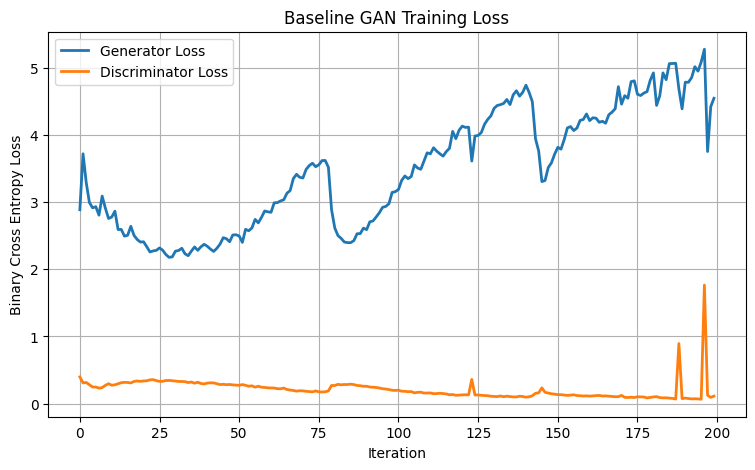

In [ ]:
plt.figure(figsize=(9,5))
plt.plot(generator_losses_base, label="Generator Loss", linewidth=2)
plt.plot(discriminator_losses_base, label="Discriminator Loss", linewidth=2)
plt.title("Baseline GAN Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Binary Cross Entropy Loss")
plt.grid(True)
plt.legend()
plt.show()

Berdasarkan hasil pelatihan selama 200 epoch, terlihat bahwa generator loss cenderung meningkat dari 2.8861 menjadi 4.5451, sedangkan discriminator loss terus menurun dari 0.3980 menjadi 0.1122. Pola ini menunjukkan bahwa discriminator mampu membedakan citra asli dan citra hasil generator dengan semakin baik, sementara generator mengalami kesulitan untuk menghasilkan citra yang mampu mengecoh discriminator. Dengan demikian, keseimbangan antara kedua jaringan tidak tercapai sehingga proses adversarial didominasi oleh discriminator dan generator belum mampu mempelajari distribusi data secara optimal.

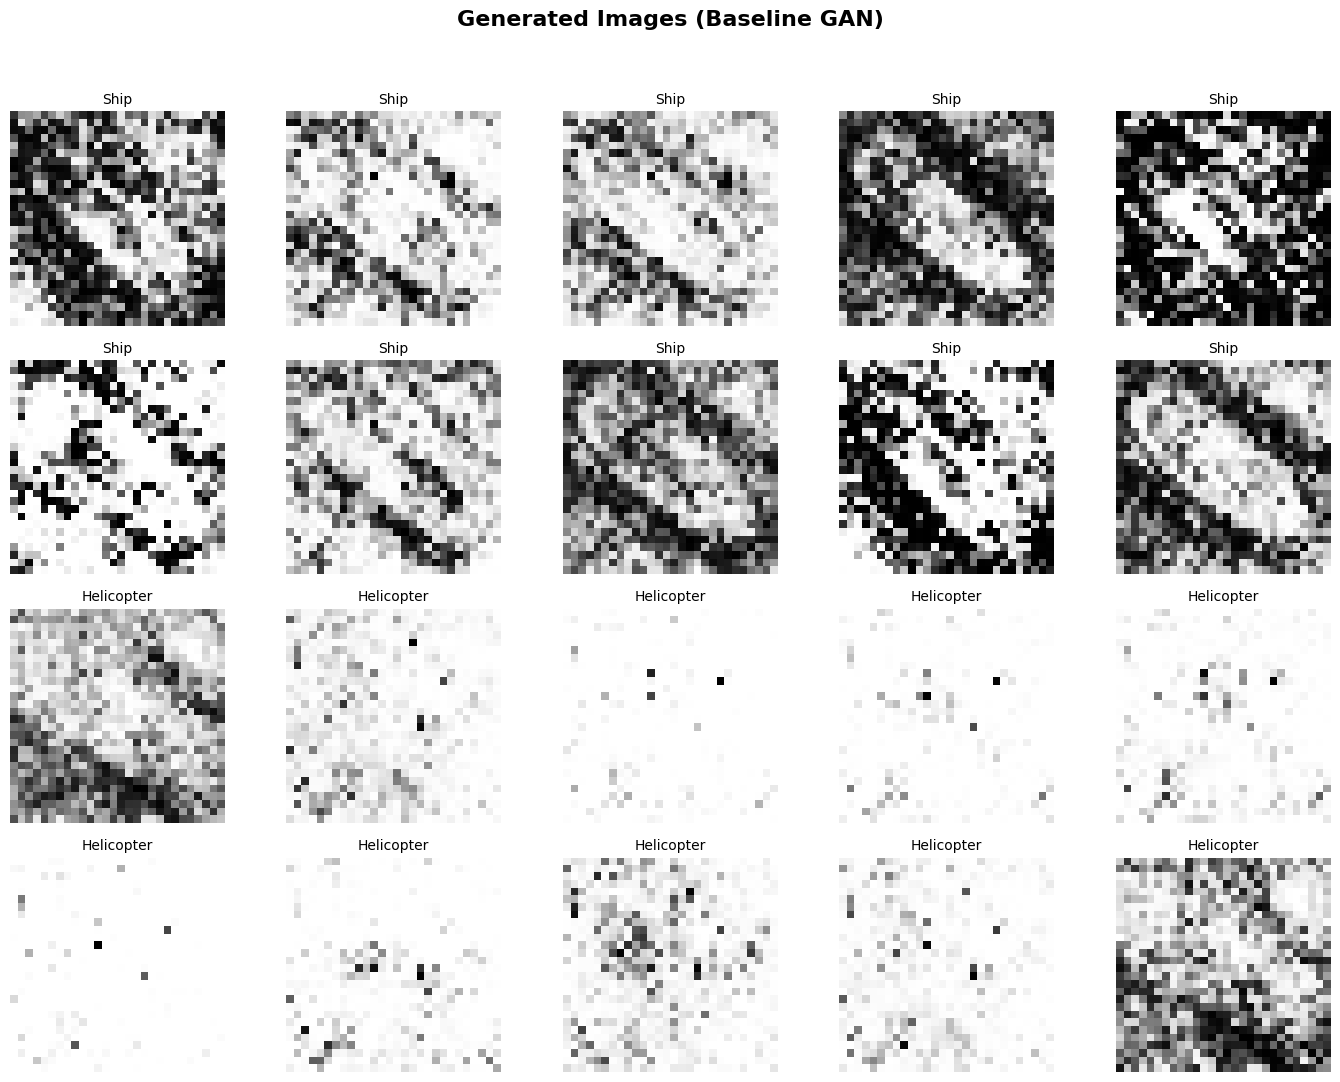

In [ ]:
fixed_noise_base = torch.randn(20, LATENT_DIM, device=DEVICE)
fixed_labels_viz = torch.tensor([0]*10 + [1]*10, dtype=torch.long, device=DEVICE)

def visualize_generated_images(generator, fixed_noise, title="Generated Images"):
    generator.eval()
    with torch.no_grad():
        fake_images = generator(fixed_noise, fixed_labels_viz)
        fake_images = (fake_images.cpu() + 1) / 2

    fig, axes = plt.subplots(4, 5, figsize=(14, 11))
    fig.suptitle(title, fontsize=16, fontweight="bold")

    for i in range(10):
        row, col = i // 5, i % 5
        axes[row, col].imshow(fake_images[i].squeeze(), cmap="gray")
        axes[row, col].set_title("Ship", fontsize=10)
        axes[row, col].axis("off")

    for i in range(10):
        row, col = 2 + (i // 5), i % 5
        axes[row, col].imshow(fake_images[i+10].squeeze(), cmap="gray")
        axes[row, col].set_title("Helicopter", fontsize=10)
        axes[row, col].axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
    generator.train()

visualize_generated_images(generator, fixed_noise_base, title="Generated Images (Baseline GAN)")

Hasil generated image dari model baseline menunjukkan kualitas yang masih sangat rendah. Sebagian besar gambar masih berupa pola piksel acak (noise) dan belum membentuk karakteristik visual yang menyerupai objek ship maupun helicopter. Bahkan, tanpa adanya label kelas, gambar yang dihasilkan sulit diidentifikasi sebagai kedua objek tersebut. Hal ini menunjukkan bahwa arsitektur baseline belum mampu menangkap informasi spasial pada citra sehingga generator belum dapat menghasilkan gambar yang realistis.

In [ ]:
fid_model = InceptionV3(include_top=False, pooling="avg", input_shape=(299, 299, 3), weights="imagenet")

def calculate_fid(generator, dataloader, latent_dim, device, eps=1e-6):
    generator.eval()
    real_images, fake_images = [], []

    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs = imgs.to(device)
            labels = labels.to(device)
            noise = torch.randn(imgs.size(0), latent_dim, device=device)
            generated = generator(noise, labels)
            real_images.append(imgs.cpu())
            fake_images.append(generated.cpu())

    real_images = torch.cat(real_images, dim=0)
    fake_images = torch.cat(fake_images, dim=0)

    real_images = ((real_images + 1) / 2).numpy()
    fake_images = ((fake_images + 1) / 2).numpy()

    real_images = np.repeat(np.transpose(real_images, (0, 2, 3, 1)), 3, axis=-1)
    fake_images = np.repeat(np.transpose(fake_images, (0, 2, 3, 1)), 3, axis=-1)

    real_images = preprocess_input(tf.image.resize(real_images, (299, 299)).numpy() * 255.0)
    fake_images = preprocess_input(tf.image.resize(fake_images, (299, 299)).numpy() * 255.0)

    act_real = fid_model.predict(real_images.astype(np.float32), verbose=0)
    act_fake = fid_model.predict(fake_images.astype(np.float32), verbose=0)

    mu_real, mu_fake = np.mean(act_real, axis=0), np.mean(act_fake, axis=0)
    sigma_real = np.cov(act_real, rowvar=False) + np.eye(act_real.shape[1]) * eps
    sigma_fake  = np.cov(act_fake, rowvar=False) + np.eye(act_fake.shape[1]) * eps

    covmean = sqrtm(sigma_real @ sigma_fake)
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    diff = mu_real - mu_fake
    fid = diff @ diff + np.trace(sigma_real + sigma_fake - 2 * covmean)

    generator.train()
    return float(fid)

torch.manual_seed(SEED)
fid_baseline = calculate_fid(generator, test_loader, LATENT_DIM, DEVICE)

print("Baseline GAN")
print("-" * 40)
print(f"FID Score : {fid_baseline:.4f}")

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Baseline GAN
----------------------------------------
FID Score : 291.1607


Model baseline menghasilkan FID Score sebesar 291.1607, yang menunjukkan bahwa distribusi citra hasil generator masih sangat berbeda dengan distribusi citra asli. Nilai FID yang cukup tinggi ini mengindikasikan bahwa kualitas gambar yang dihasilkan masih rendah dan belum realistis. Hasil tersebut juga konsisten dengan visualisasi generated image yang menunjukkan bahwa generator belum mampu menghasilkan objek ship maupun helicopter yang dapat dikenali dengan baik.

## Modification

### Modified GAN Architecture

- **Generator dimodifikasi menggunakan arsitektur DCGAN**  
Generator diubah dari arsitektur MLP menjadi kombinasi Linear Projection, ConvTranspose2D, dan Conv2D sehingga mampu mempelajari struktur spasial citra dengan lebih baik. Dibandingkan baseline yang hanya menggunakan Fully Connected Layer, arsitektur ini menghasilkan citra yang lebih realistis dan menurunkan nilai FID secara signifikan.
- **Discriminator dimodifikasi menggunakan Convolutional Layer**   
Fully Connected Layer diganti dengan Convolutional Layer sehingga discriminator dapat mengekstraksi fitur spasial seperti tepi, tekstur, dan bentuk objek secara lebih efektif. Hal ini membuat proses pembelajaran generator menjadi lebih baik karena menerima umpan balik yang lebih akurat.
- **Batch Normalization**    
Ditambahkan setelah Linear layer dan ConvTranspose2D pada generator serta convolution layer pada discriminator untuk menstabilkan distribusi aktivasi, mempercepat konvergensi, dan membuat proses training lebih stabil dibandingkan baseline.
- **Latent Dimension ditingkatkan menjadi 128**   
Ukuran latent vector diperbesar agar generator dapat merepresentasikan variasi karakteristik citra yang lebih kaya sehingga gambar yang dihasilkan memiliki kualitas dan keragaman yang lebih baik.
- **Label Embedding ditingkatkan menjadi 64**   
Dimensi embedding diperbesar agar informasi kelas (ship dan helicopter) dapat direpresentasikan dengan lebih baik sehingga generator mampu menghasilkan citra yang lebih sesuai dengan label yang diberikan.
- **Weight Initialization**   
Menggunakan Normal Initialization pada layer konvolusi dan Xavier Initialization pada layer linear untuk menjaga distribusi bobot pada awal pelatihan sehingga proses optimasi menjadi lebih stabil dan lebih cepat mencapai konvergensi.

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE = 28
IMG_CHANNELS = 1
N_CLASSES = len(CLASSES)

LATENT_DIM_MOD = 128
EMBED_DIM_MOD = 64
FEATURES_G = 64
FEATURES_D = 64

print("Device :", DEVICE)

class Mod_Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_embedding = nn.Embedding(N_CLASSES, EMBED_DIM_MOD)

        self.project = nn.Sequential(
            nn.Linear(LATENT_DIM_MOD + EMBED_DIM_MOD, FEATURES_G * 4 * 7 * 7),
            nn.BatchNorm1d(FEATURES_G * 4 * 7 * 7),
            nn.ReLU(True)
        )

        self.model = nn.Sequential(
            nn.ConvTranspose2d(FEATURES_G * 4, FEATURES_G * 2, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(FEATURES_G * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(FEATURES_G * 2, FEATURES_G, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(FEATURES_G),
            nn.ReLU(True),
            nn.Conv2d(FEATURES_G, IMG_CHANNELS, kernel_size=3, stride=1, padding=1),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        label_embedding = self.label_embedding(labels)
        x = torch.cat([noise, label_embedding], dim=1)
        x = self.project(x)
        x = x.view(-1, FEATURES_G * 4, 7, 7)
        generated_image = self.model(x)
        return generated_image

class Mod_Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.label_embedding = nn.Embedding(N_CLASSES, IMG_SIZE * IMG_SIZE)

        self.model = nn.Sequential(
            nn.Conv2d(2, FEATURES_D, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(FEATURES_D, FEATURES_D * 2, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(FEATURES_D * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Flatten(),
            nn.Linear(FEATURES_D * 2 * 7 * 7, 1),
            nn.Sigmoid()
        )

    def forward(self, image, labels):
        label_embedding = self.label_embedding(labels)
        label_embedding = label_embedding.view(-1, 1, IMG_SIZE, IMG_SIZE)
        x = torch.cat([image, label_embedding], dim=1)
        probability = self.model(x)
        return probability

def weights_init(module):
    classname = module.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(module.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(module.weight.data, 1.0, 0.02)
        nn.init.constant_(module.bias.data, 0)
    elif classname.find("Linear") != -1:
        nn.init.xavier_normal_(module.weight.data)
        if module.bias is not None:
            nn.init.constant_(module.bias.data, 0)

Device : cuda


### Hyperparameter Tuning

- **Adam Optimizer**   
Digunakan karena mampu menyesuaikan learning rate secara adaptif sehingga proses optimasi menjadi lebih cepat dan stabil.
- **Learning Rate sebesar 2×10⁻⁴**   
Dipilih karena memberikan keseimbangan pembelajaran antara generator dan discriminator, sehingga menghasilkan performa yang lebih baik selama proses training.
- **Binary Cross Entropy (BCE) Loss**   
Digunakan karena sesuai untuk tugas klasifikasi biner pada GAN, sehingga generator dan discriminator dapat belajar secara efektif dalam membedakan citra asli dan citra hasil generasi.
- **One-Sided Label Smoothing (Real Label = 0.9)**   
Diterapkan agar discriminator tidak menjadi terlalu percaya diri terhadap data asli sehingga generator tetap memperoleh gradien yang cukup untuk menghasilkan citra yang lebih realistis dan membantu menurunkan nilai FID.

In [ ]:
mod_generator = Mod_Generator().to(DEVICE)
mod_discriminator = Mod_Discriminator().to(DEVICE)

mod_generator.apply(weights_init)
mod_discriminator.apply(weights_init)

optimizer_G_mod = torch.optim.Adam(mod_generator.parameters(), lr=2e-4, betas=(0.5, 0.999))
optimizer_D_mod = torch.optim.Adam(mod_discriminator.parameters(), lr=2e-4, betas=(0.5, 0.999))
criterion_mod = nn.BCELoss()

print("=== MODIFIED GENERATOR ===")
print(mod_generator)
print(f"\nTotal params Mod_Generator     : {sum(p.numel() for p in mod_generator.parameters()):,}")

print("\n=== MODIFIED DISCRIMINATOR ===")
print(mod_discriminator)
print(f"\nTotal params Mod_Discriminator : {sum(p.numel() for p in mod_discriminator.parameters()):,}")

=== MODIFIED GENERATOR ===
Mod_Generator(
  (label_embedding): Embedding(2, 64)
  (project): Sequential(
    (0): Linear(in_features=192, out_features=12544, bias=True)
    (1): BatchNorm1d(12544, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (model): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Conv2d(64, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): Tanh()
  )
)

Total params Mod_Generator     : 3,102,721

=== MODIFIED DISCRIMINATOR ===
Mod_Discriminator(
  (label_embedding): Embedding(2, 784)
  (model): Sequential(
    (0): Conv2d(2, 64, ke

In [ ]:
mod_noise = torch.randn(4, LATENT_DIM_MOD).to(DEVICE)
mod_labels = torch.tensor([0, 1, 0, 1], dtype=torch.long).to(DEVICE)

mod_generated_images = mod_generator(mod_noise, mod_labels)
mod_prediction = mod_discriminator(mod_generated_images, mod_labels)

print("\nMod Generator Output Shape     :", mod_generated_images.shape)
print("Mod Discriminator Output Shape :", mod_prediction.shape)


Mod Generator Output Shape     : torch.Size([4, 1, 28, 28])
Mod Discriminator Output Shape : torch.Size([4, 1])


In [ ]:
def train_modified_gan(generator, discriminator, dataloader, optimizer_G, optimizer_D,
                       criterion, epochs, latent_dim, device):
    generator.train()
    discriminator.train()
    generator_losses = []
    discriminator_losses = []

    for epoch in range(epochs):
        g_epoch_loss = 0.0
        d_epoch_loss = 0.0

        for real_images, labels in dataloader:
            real_images = real_images.to(device)
            labels = labels.to(device)
            batch_size  = real_images.size(0)

            real_targets = torch.full((batch_size, 1), 0.9, device=device)
            fake_targets = torch.zeros(batch_size, 1, device=device)

            optimizer_D.zero_grad()
            real_output = discriminator(real_images, labels)
            d_real_loss = criterion(real_output, real_targets)

            noise = torch.randn(batch_size, latent_dim, device=device)
            fake_images = generator(noise, labels).detach()
            fake_output = discriminator(fake_images, labels)
            d_fake_loss = criterion(fake_output, fake_targets)

            d_loss = (d_real_loss + d_fake_loss) / 2
            d_loss.backward()
            optimizer_D.step()

            optimizer_G.zero_grad()
            noise = torch.randn(batch_size, latent_dim, device=device)
            fake_images = generator(noise, labels)
            output = discriminator(fake_images, labels)
            g_loss = criterion(output, real_targets)
            g_loss.backward()
            optimizer_G.step()

            g_epoch_loss += g_loss.item()
            d_epoch_loss += d_loss.item()

        g_epoch_loss /= len(dataloader)
        d_epoch_loss /= len(dataloader)
        generator_losses.append(g_epoch_loss)
        discriminator_losses.append(d_epoch_loss)

        if (epoch + 1) % 20 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1:3d}/{epochs}] "
                  f"| G Loss : {g_epoch_loss:.4f} "
                  f"| D Loss : {d_epoch_loss:.4f}")

    return generator_losses, discriminator_losses

In [ ]:
EPOCHS_MOD = 200

generator_losses_mod, discriminator_losses_mod = train_modified_gan(
    mod_generator, mod_discriminator, train_loader,
    optimizer_G_mod, optimizer_D_mod, criterion_mod,
    epochs=EPOCHS_MOD, latent_dim=LATENT_DIM_MOD, device=DEVICE
)

Epoch [  1/200] | G Loss : 1.4712 | D Loss : 0.6527
Epoch [ 20/200] | G Loss : 0.8686 | D Loss : 0.6875
Epoch [ 40/200] | G Loss : 0.8708 | D Loss : 0.6719
Epoch [ 60/200] | G Loss : 0.8687 | D Loss : 0.6662
Epoch [ 80/200] | G Loss : 0.8942 | D Loss : 0.6533
Epoch [100/200] | G Loss : 0.9302 | D Loss : 0.6383
Epoch [120/200] | G Loss : 0.9736 | D Loss : 0.6158
Epoch [140/200] | G Loss : 1.0298 | D Loss : 0.5973
Epoch [160/200] | G Loss : 1.0962 | D Loss : 0.5746
Epoch [180/200] | G Loss : 1.1614 | D Loss : 0.5549
Epoch [200/200] | G Loss : 1.2278 | D Loss : 0.5350


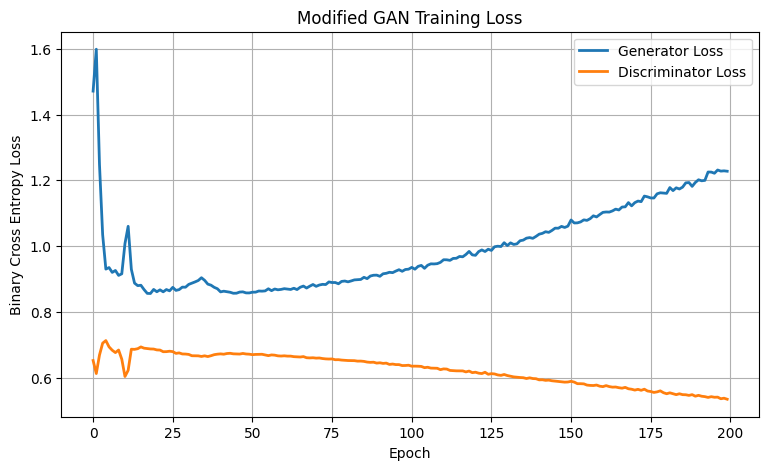

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(generator_losses_mod, label="Generator Loss", linewidth=2)
plt.plot(discriminator_losses_mod, label="Discriminator Loss", linewidth=2)
plt.title("Modified GAN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross Entropy Loss")
plt.grid(True)
plt.legend()
plt.show()

Training loss pada model modifikasi menunjukkan proses pembelajaran yang lebih stabil dibandingkan baseline. Generator loss sempat turun pada awal pelatihan sebelum meningkat secara bertahap, sementara discriminator loss terus menurun dari 0.65 menjadi 0.54, menunjukkan bahwa discriminator semakin baik dalam membedakan citra asli dan hasil generasi. Pola ini mengindikasikan kedua jaringan tetap saling belajar selama proses training. Stabilitas tersebut didukung oleh penggunaan arsitektur DCGAN, Batch Normalization, dan label embedding yang lebih sesuai untuk pemrosesan citra.

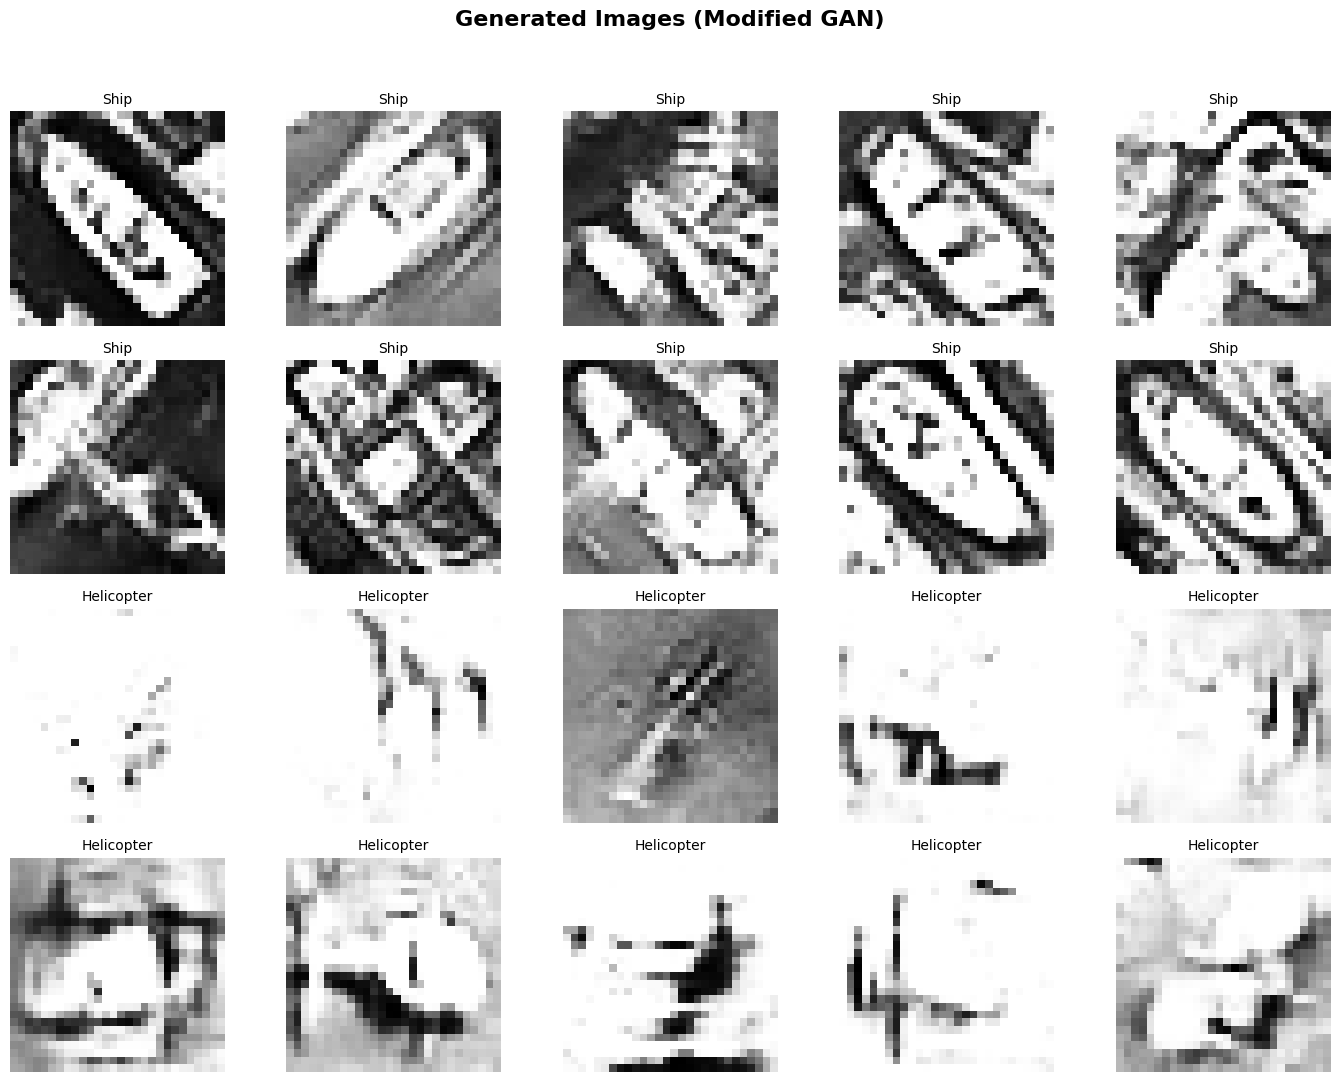

In [ ]:
fixed_noise_mod  = torch.randn(20, LATENT_DIM_MOD, device=DEVICE)
visualize_generated_images(mod_generator, fixed_noise_mod, title="Generated Images (Modified GAN)")

Visualisasi hasil generasi menunjukkan peningkatan yang sangat signifikan dibandingkan model baseline. Pada model baseline, sebagian besar gambar masih berupa pola acak sehingga sulit dikenali sebagai objek ship maupun helicopter. Sebaliknya, pada model modifikasi sebagian besar citra telah memperlihatkan bentuk dan siluet objek yang jelas, seperti badan kapal, badan helikopter, maupun posisi baling-baling, meskipun masih terdapat beberapa sampel yang tampak sedikit kabur atau memiliki detail yang belum sempurna. Selain itu, variasi antar gambar juga lebih beragam sehingga menunjukkan bahwa generator tidak hanya menghasilkan pola yang sama secara berulang.

## Baseline VS Modified

In [ ]:
torch.manual_seed(SEED)
fid_modified = calculate_fid(mod_generator, test_loader, LATENT_DIM_MOD, DEVICE)

improvement = fid_baseline - fid_modified
percentage = improvement / fid_baseline * 100

print(f"{'Model':<30} {'FID Score':>12}")
print("-" * 50)
print(f"{'Baseline GAN (MLP)':<30} {fid_baseline:>12.4f}")
print(f"{'Modified GAN (DCGAN)':<30} {fid_modified:>12.4f}")
print("-" * 50)
print(f"{'Improvement':<30} {improvement:>12.4f}")
print(f"{'Improvement (%)':<30} {percentage:>11.2f}%")

Model                             FID Score
--------------------------------------------------
Baseline GAN (MLP)                 291.1607
Modified GAN (DCGAN)                64.5903
--------------------------------------------------
Improvement                        226.5704
Improvement (%)                      77.82%


Peningkatan kualitas visual tersebut sejalan dengan hasil evaluasi menggunakan Fréchet Inception Distance (FID), di mana nilai **FID berhasil turun dari 291.1607 pada model baseline menjadi 64.5903 pada model modifikasi**, atau mengalami **peningkatan performa sekitar 77.82**%. Penurunan FID yang cukup besar menunjukkan bahwa distribusi citra sintetis yang dihasilkan semakin mendekati distribusi citra asli. Perbaikan ini diperoleh karena arsitektur DCGAN memanfaatkan operasi convolution dan transposed convolution yang mampu mempertahankan informasi spasial selama proses pembentukan citra, berbeda dengan arsitektur MLP pada baseline yang mengolah citra sebagai vektor satu dimensi sehingga kurang efektif dalam mempelajari pola visual. Ditambah dengan penggunaan Batch Normalization, label embedding yang lebih representatif, serta hyperparameter tuning yang lebih sesuai, proses pembelajaran menjadi lebih stabil dan menghasilkan kualitas citra yang jauh lebih baik.

In [ ]:
torch.save(
    mod_generator.state_dict(),
    "best_modified_generator.pth"
)

torch.save(
    mod_discriminator.state_dict(),
    "best_modified_discriminator.pth"
)